# Trabajo Final Integrador: NLP + Deep Learning
## Materia: Data Science III
### Alumno: Mauricio Carbonelli
### Comisión: #95850
### Caso de Estudio: Análisis de Sentimiento en Comentarios de Redes Sociales (Electrín S.A.)

---

### Introduccion y Objetivos
Para la entrega final de la materia decidí encarar un problema real y bien cotidiano: el análisis de la percepción de los usuarios frente a los servicios públicos, específicamente una empresa distribuidora de energía eléctrica a la que llamé ficticiamente **Electrín**.

En el día a día, la empresa publica en Instagram distintos tipos de comunicados (cortes programados por mantenimiento, avisos de cortes imprevistos por tormentas, recordatorios de pago de facturas, canales de atención al cliente y obras de alumbrado). Mi objetivo en este proyecto es procesar esos comentarios mediante técnicas de **NLP** y entrenar modelos de **Deep Learning** para clasificar automáticamente si el comentario refleja una queja/reclamo o una satisfacción/agradecimiento.

Organicé el desarrollo de mi trabajo siguiendo todos los puntos solicitados en la consigna:
1. **Parte A (NLP):** Carga del dataset, análisis exploratorio de datos (EDA) y pipeline de preprocesamineto (limpieza con regex, tokenización, remoción de stopwords y vectorización TF-IDF con unigramas y bigramas).
2. **Parte B (Deep Learning Mínimo):** Partición de datos, modelos baseline de referencia (Regresión Logística y Naive Bayes) y construcción de mi primera Red Neuronal Simple (MLP de 1 capa oculta).
3. **Parte C (Profundización de Deep Learning):** Desarrollo de una Red Neuronal Profunda (DNN) incorporando múltiples capas densas, regularización con Dropout, Batch Normalization y optimizador Adam; comparación exhaustiva de métricas, matrices de confusión, curvas de aprendizaje y un simulador de inferencia en tiempo real para evaluar comentarios inéditos.


## 1. Importación de Librerías y Configuración

En esta primer celda importo todas las librerías necesarias para el proyeto: pandas y numpy para manipular los datos, matplotlib y seaborn para las visualizaciones, scikit-learn para la vectorización y métricas de evaluación, y TensorFlow / Keras para la construcción y entrenamiento de las redes neuronales.

Además, fijo una semilla (`SEED = 42`) para garantizar que cada ejecución sea 100% reproducible y arroje exactamente los mismos resultados.


In [3]:
import re
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# NLP y visualizaciones de texto
from wordcloud import WordCloud

# Machine Learning y Métricas
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

# Deep Learning (Keras / TensorFlow)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks

# Fijo semilla para que el trabajo sea 100% reproducible
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Configuro el estilo visual de los gráficos
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['font.size'] = 10

print("Librerías importadas correctamente. Versión de TensorFlow:", tf.__version__)


Librerías importadas correctamente. Versión de TensorFlow: 2.21.0


## 2. Carga y Exploración Inicial del Dataset

Cargo el dataset `comentarios_instagram_electrin.csv` que preparé para este estudio. El archivo contiene 1.050 comentarios en español con una distribución natural (58% quejas y 42% positivos) que refleja la interacción cotidiana en las redes de una distribuidora eléctrica:
* **`0`:** Sentimiento Negativo / Reclamo (quejas por falta de luz, artefactos quemados, subas de luz, problemas con la app, demoras en la atención, incluyendo comentarios con ironía o sarcasmo).
* **`1`:** Sentimiento Positivo / Agradecimiento (felicitaciones por restablecer rápido el servicio, avisos claros de cortes programados, buena atención, obras nuevas).

Incluí en los textos el ruido típico de redes sociales: menciones (`@electrin_oficial`), hashtags (`#SinLuz`, `#CorteProgramado`), emojis (`😡`, `⚡`, `👏`), signos de puntuación repetidos y enlaces.


In [5]:
# Cargo el dataset desde archivo local o directamente desde mi repositorio en GitHub (para Google Colab)
csv_local = "comentarios_instagram_electrin.csv"
url_github = "https://raw.githubusercontent.com/mcarbonelli/DSIII-Final/main/comentarios_instagram_electrin.csv"

if os.path.exists(csv_local):
    df = pd.read_csv(csv_local)
    print(f"Dataset cargado desde archivo local ({len(df)} registros).")
else:
    df = pd.read_csv(url_github)
    print(f"Dataset cargado exitosamente desde GitHub ({len(df)} registros).")

print(f"Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas\n")
print(df.head(6))


Dataset cargado desde archivo local (1050 registros).
Dimensiones del dataset: 1050 filas x 5 columnas

   id  ... sentimiento
0   1  ...           0
1   2  ...           1
2   3  ...           0
3   4  ...           0
4   5  ...           0
5   6  ...           0

[6 rows x 5 columns]


In [6]:
# Reviso los tipos de datos y compruebo si existen valores nulos
print("Resumen de columnas y tipos de datos:")
df.info()
print("\nComprobación de valores nulos:")
print(df.isnull().sum())


Resumen de columnas y tipos de datos:
<class 'pandas.DataFrame'>
RangeIndex: 1050 entries, 0 to 1049
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   id              1050 non-null   int64
 1   fecha           1050 non-null   str  
 2   categoria_post  1050 non-null   str  
 3   texto_original  1050 non-null   str  
 4   sentimiento     1050 non-null   int64
dtypes: int64(2), str(3)
memory usage: 41.1 KB

Comprobación de valores nulos:
id                0
fecha             0
categoria_post    0
texto_original    0
sentimiento       0
dtype: int64


## 3. Análisis Exploratorio de Datos (EDA)

Antes de avanzar con la limpieza del texto, realizo un análisis exploratorio (EDA) para entender las características del corpus:
1. Verifico la distribución de clases (notando el desbalance natural hacia los reclamos típico de este sector).
2. Analizo el volumen de comentarios por cada tipo de publicación (cortes, facturación, obras, atención).
3. Examino la longitud de los textos (cantidad de palabras por comentario).
4. Genero nubes de palabras (*WordClouds*) para identificar qué términos predominan en las quejas y cuáles en los agradecimientos.


Distribución porcentual de clases:
sentimiento
0    58.10%
1    41.90%
Name: proportion, dtype: str


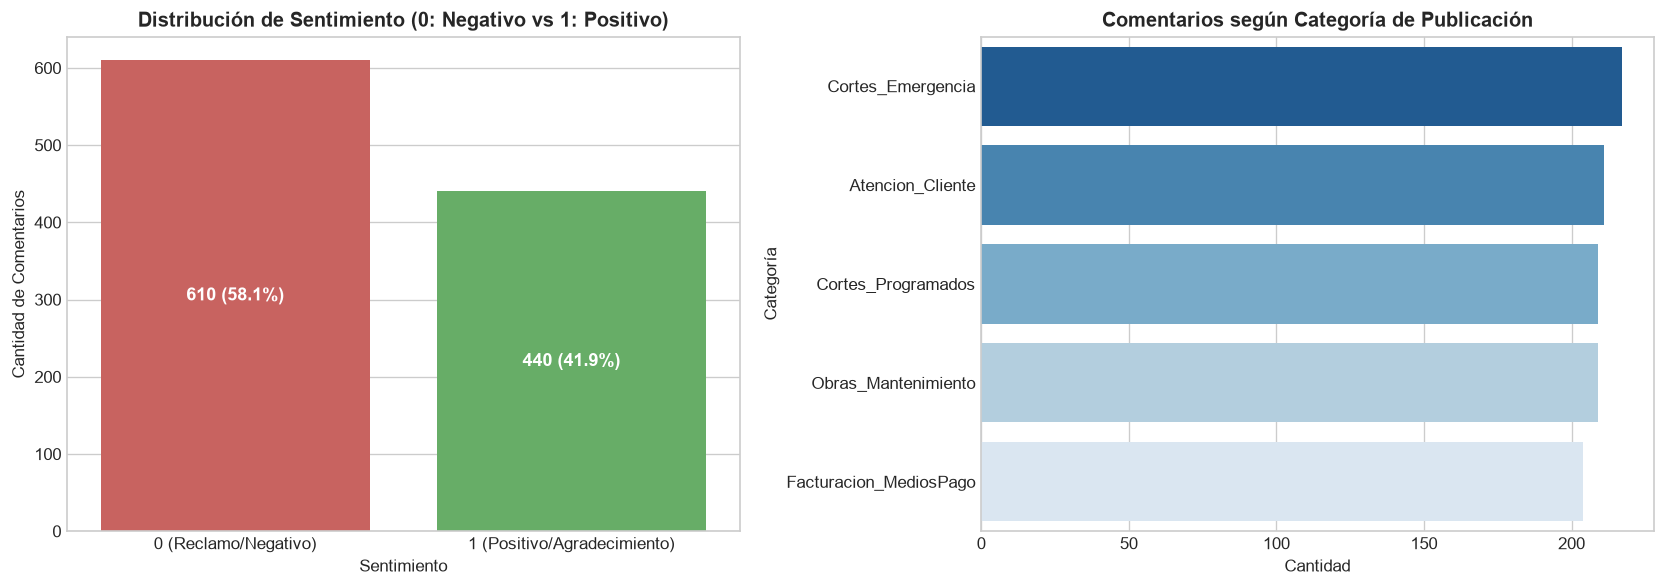

In [8]:
# 1. Grafico la distribución de sentimiento y categorías de publicación
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución de clases
colores = ['#d9534f', '#5cb85c']
sns.countplot(data=df, x='sentimiento', ax=axes[0], palette=colores)
axes[0].set_title('Distribución de Sentimiento (0: Negativo vs 1: Positivo)', fontweight='bold')
axes[0].set_xlabel('Sentimiento')
axes[0].set_ylabel('Cantidad de Comentarios')
axes[0].set_xticklabels(['0 (Reclamo/Negativo)', '1 (Positivo/Agradecimiento)'])
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height())} ({p.get_height()/len(df)*100:.1f}%)", 
                     (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                     ha='center', va='center', color='white', fontweight='bold', fontsize=11)

# Distribución por categoría de post
sns.countplot(data=df, y='categoria_post', ax=axes[1], palette='Blues_r', order=df['categoria_post'].value_counts().index)
axes[1].set_title('Comentarios según Categoría de Publicación', fontweight='bold')
axes[1].set_xlabel('Cantidad')
axes[1].set_ylabel('Categoría')

plt.tight_layout()
plt.show()

print("Distribución porcentual de clases:")
print(df['sentimiento'].value_counts(normalize=True).apply(lambda x: f"{x*100:.2f}%"))


Resumen estadístico de palabras por sentimiento:
             count  mean  std   min   25%   50%   75%   max
sentimiento                                                
0            610.0  17.9  2.8  10.0  16.0  18.0  20.0  26.0
1            440.0  16.9  2.9   9.0  15.0  17.0  19.0  26.0


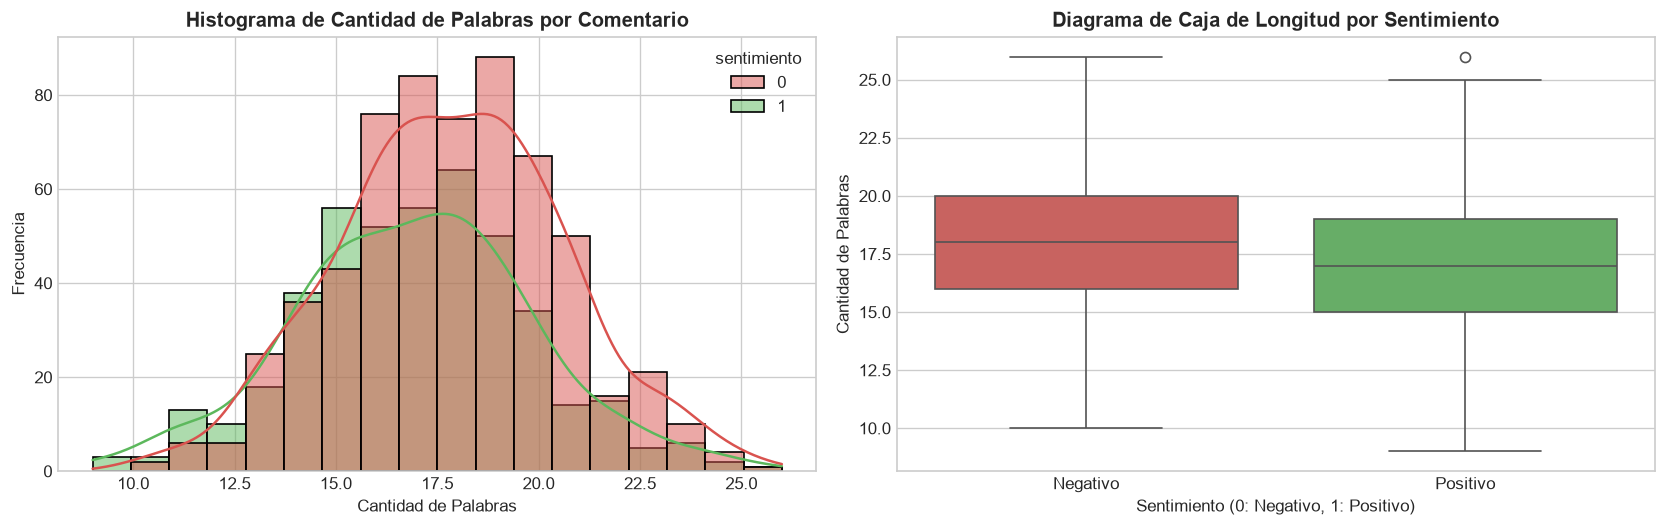

In [9]:
# 2. Analizo la longitud de los comentarios en cantidad de palabras
df['cant_palabras'] = df['texto_original'].apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.histplot(data=df, x='cant_palabras', hue='sentimiento', kde=True, ax=axes[0], palette=colores, bins=18)
axes[0].set_title('Histograma de Cantidad de Palabras por Comentario', fontweight='bold')
axes[0].set_xlabel('Cantidad de Palabras')
axes[0].set_ylabel('Frecuencia')

sns.boxplot(data=df, x='sentimiento', y='cant_palabras', ax=axes[1], palette=colores)
axes[1].set_title('Diagrama de Caja de Longitud por Sentimiento', fontweight='bold')
axes[1].set_xlabel('Sentimiento (0: Negativo, 1: Positivo)')
axes[1].set_ylabel('Cantidad de Palabras')
axes[1].set_xticklabels(['Negativo', 'Positivo'])

plt.tight_layout()
plt.show()

print("Resumen estadístico de palabras por sentimiento:")
print(df.groupby('sentimiento')['cant_palabras'].describe().round(1))


## 4. Pipeline de Preprocesamiento de NLP

El texto crudo proveniente de redes sociales contiene mucho ruido que no aporta valor a los modelos. Para procesarlo, diseñé e implementé un pipeline con las **4 tareas clásicas de NLP**:

1. **Limpieza con Regex y Normalización:** convierto todo el texto a minúsculas, elimino URLs, menciones de usuarios (`@...`), hashtags (`#...`), emojis, signos de puntuación y números, conservando únicamente caracteres en español (`a-z, á, é, í, ó, ú, ü, ñ`).
2. **Tokenización:** divido cada oración en palabras individuales (tokens).
3. **Remoción de Stopwords:** elimino palabras vacías (artículos, preposiciones, pronombres) que tienen alta frecuencia pero carecen de carga sentimental.
4. **Reconstrucción del texto limpio:** vuelvo a unir los tokens filtrados en una cadena limpia lista para vectorizar.


In [11]:
# Defino una lista personalizada de stopwords en español
STOPWORDS_ES = set('''
a al algo algunas algunos ante antes como con contra cual cuando de del desde donde
durante e el ella ellas ellos en entre era erais eramos eran eres es esa esas ese
esos esta estaba estabais estabamos estaban estar este esto estos fue fueron fui
fuimos ha haber habia habian han has hasta hay la las le les lo los mas me mi mis
mucho muchos muy nada ni no nos nosotros nuestra nuestro o os otra otro para pero
poco por porque que quien se ser si sin sobre son su sus te tener tiene tienen todo
todos tu tus un una uno unos y ya yo aca ahi alli
'''.split())

def limpiar_texto(texto: str) -> str:
    """Limpio el texto eliminando URLs, menciones, hashtags, emojis y caracteres especiales."""
    texto = str(texto).lower()
    texto = re.sub(r'https?://\S+|www\.\S+', ' ', texto)        # elimino URLs
    texto = re.sub(r'@\w+', ' ', texto)                         # elimino @usuarios
    texto = re.sub(r'#\w+', ' ', texto)                         # elimino #hashtags
    texto = re.sub(r'[^a-záéíóúüñ\s]', ' ', texto)               # conservo solo letras, tildes, ñ y ü
    texto = re.sub(r'\s+', ' ', texto).strip()                  # normalizo espacios múltiples
    return texto

def tokenizar(texto: str) -> list:
    """Divido el texto en una lista de tokens (palabras)."""
    return texto.split()

def quitar_stopwords(tokens: list) -> list:
    """Filtro palabras vacías y términos muy cortos."""
    return [palabra for palabra in tokens if palabra not in STOPWORDS_ES and len(palabra) > 2]

def pipeline_nlp(texto: str) -> str:
    """Aplico el pipeline completo de preprocesamiento sobre un texto."""
    t_limpio = limpiar_texto(texto)
    tokens = tokenizar(t_limpio)
    tokens_filtrados = quitar_stopwords(tokens)
    return " ".join(tokens_filtrados)

# Aplico el pipeline sobre la columna de texto original
df['texto_procesado'] = df['texto_original'].apply(pipeline_nlp)

print("Muestra comparativa del texto antes y después del procesamiento:")
print(df[['texto_original', 'texto_procesado', 'sentimiento']].head(6))


Muestra comparativa del texto antes y después del procesamiento:
                                      texto_original  ... sentimiento
0  El código QR para pagar en la web no funciona,...  ...           0
1  La oficina virtual es súper intuitiva y te per...  ...           1
2  Trámite de cambio de titularidad rechazado tre...  ...           0
3  Imposible trabajar desde casa con estos cortes...  ...           0
4  Genial la puntualidad de Electrín, prometieron...  ...           0
5  Postes viejos de madera podridos que nunca ree...  ...           0

[6 rows x 3 columns]


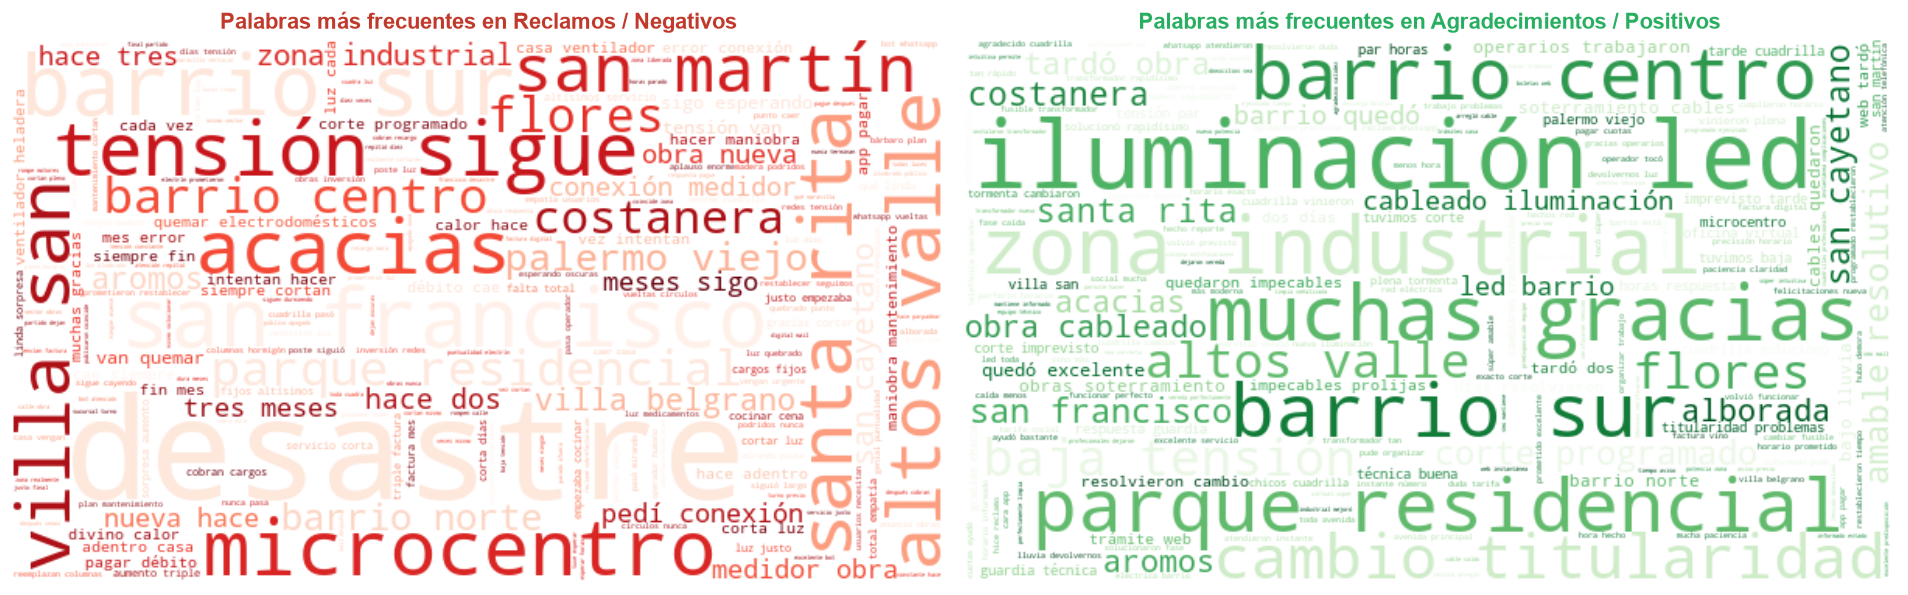

In [12]:
# 3. Construyo nubes de palabras (WordClouds) para visualizar términos frecuentes
texto_neg = " ".join(df[df['sentimiento'] == 0]['texto_procesado'])
texto_pos = " ".join(df[df['sentimiento'] == 1]['texto_procesado'])

wc_neg = WordCloud(width=600, height=350, background_color='white', colormap='Reds', random_state=SEED).generate(texto_neg)
wc_pos = WordCloud(width=600, height=350, background_color='white', colormap='Greens', random_state=SEED).generate(texto_pos)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(wc_neg, interpolation='bilinear')
axes[0].set_title('Palabras más frecuentes en Reclamos / Negativos', fontweight='bold', fontsize=13, color='#c0392b')
axes[0].axis('off')

axes[1].imshow(wc_pos, interpolation='bilinear')
axes[1].set_title('Palabras más frecuentes en Agradecimientos / Positivos', fontweight='bold', fontsize=13, color='#27ae60')
axes[1].axis('off')

plt.tight_layout()
plt.show()


## 5. Vectorización Numérica (TF-IDF) y Train / Test Split

Dado que las redes neuronales y los algoritmos de machine learning operan sobre matrices numéricas, transformo los textos procesados mediante **TF-IDF (Term Frequency - Inverse Document Frequency)**.

Configuré el vectorizador con `max_features=1500` y `ngram_range=(1, 2)` para capturar tanto palabras individuales (unigramas) como frases de dos palabras (bigramas como *'corte programado'*, *'baja tension'*, *'debito automatico'* o *'buena atencion'*).

Posteriormente, divido el dataset en:
* **80% para entrenamiento (Train)**
* **20% para evaluación (Test)**

Utilizo `stratify=y` para asegurar que la proporción entre reclamos y agradecimientos se mantenga idéntica en ambos conjuntos.


In [14]:
# Configuro el vectorizador TF-IDF con unigramas y bigramas
vectorizador_tfidf = TfidfVectorizer(max_features=1500, ngram_range=(1, 2))
X = vectorizador_tfidf.fit_transform(df['texto_procesado']).toarray()
y = df['sentimiento'].values

print(f"Matriz TF-IDF generada: {X.shape[0]} comentarios x {X.shape[1]} características (vocabulario)")

# Divido el conjunto de datos en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

print(f"Muestras de Entrenamiento (Train): {X_train.shape[0]} filas")
print(f"Muestras de Prueba (Test):         {X_test.shape[0]} filas")


Matriz TF-IDF generada: 1050 comentarios x 1500 características (vocabulario)
Muestras de Entrenamiento (Train): 840 filas
Muestras de Prueba (Test):         210 filas


## 6. Modelos Base de Machine Learning (Baselines)

Antes de construir las redes neuronales, entreno dos modelos clásicos de Machine Learning que me servirán como punto de referencia (*baselines*):
1. **Regresión Logística (*Logistic Regression*):** clasificador lineal muy eficiente y robusto para clasificación de texto.
2. **Multinomial Naive Bayes:** modelo probabilístico basado en el teorema de Bayes, ampliamente utilizado en tareas de NLP.


In [16]:
# 1. Entreno y evalúo el modelo de Regresión Logística
modelo_lr = LogisticRegression(random_state=SEED, max_iter=1000)
modelo_lr.fit(X_train, y_train)
y_pred_lr = modelo_lr.predict(X_test)

# 2. Entreno y evalúo el modelo Multinomial Naive Bayes
modelo_nb = MultinomialNB()
modelo_nb.fit(X_train, y_train)
y_pred_nb = modelo_nb.predict(X_test)

print("=== REPORTE: REGRESIÓN LOGÍSTICA ===")
print(classification_report(y_test, y_pred_lr, target_names=['Negativo (0)', 'Positivo (1)'], digits=4))

print("=== REPORTE: NAIVE BAYES ===")
print(classification_report(y_test, y_pred_nb, target_names=['Negativo (0)', 'Positivo (1)'], digits=4))


=== REPORTE: REGRESIÓN LOGÍSTICA ===
              precision    recall  f1-score   support

Negativo (0)     1.0000    1.0000    1.0000       122
Positivo (1)     1.0000    1.0000    1.0000        88

    accuracy                         1.0000       210
   macro avg     1.0000    1.0000    1.0000       210
weighted avg     1.0000    1.0000    1.0000       210

=== REPORTE: NAIVE BAYES ===
              precision    recall  f1-score   support

Negativo (0)     1.0000    0.9836    0.9917       122
Positivo (1)     0.9778    1.0000    0.9888        88

    accuracy                         0.9905       210
   macro avg     0.9889    0.9918    0.9902       210
weighted avg     0.9907    0.9905    0.9905       210



## 7. Mínimo de Deep Learning: Red Neuronal Simple (1 Capa Oculta)

Cumpliendo con el requerimiento de Deep Learning mínimo de la consigna, construyo mi primera **Red Neuronal Artificial (MLP)** utilizando Keras:
* **Capa de Entrada:** Recibe las 1.500 características de la matriz TF-IDF.
* **Capa Oculta:** 16 neuronas densas con función de activación no lineal **ReLU**.
* **Capa de Salida:** 1 sola neurona con función **Sigmoide**, que arroja una probabilidad continua entre 0 y 1.
* **Compilación:** Utilizo la función de pérdida `binary_crossentropy` y el optimizador `Adam`.


In [18]:
# Defino la arquitectura de mi Red Neuronal Simple
red_simple = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],), name="Entrada_TFIDF"),
    layers.Dense(16, activation='relu', name="Capa_Oculta_16_ReLU"),
    layers.Dense(1, activation='sigmoid', name="Salida_Sigmoide")
], name="Red_Neuronal_Simple_1Capa")

red_simple.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

red_simple.summary()


Model: "Red_Neuronal_Simple_1Capa"
┌─────────────────────────────────┬────────────────────────┬───────────────┐
│ Layer (type)                    │ Output Shape           │       Param # │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Capa_Oculta_16_ReLU (Dense)     │ (None, 16)             │        24,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Salida_Sigmoide (Dense)         │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘
 Total params: 24,033 (93.88 KB)
 Trainable params: 24,033 (93.88 KB)
 Non-trainable params: 0 (0.00 B)


In [19]:
# Entreno la Red Simple durante 15 épocas
history_simple = red_simple.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=15,
    batch_size=32,
    verbose=1
)

# Evalúo el rendimiento en el conjunto de prueba
y_prob_simple = red_simple.predict(X_test).flatten()
y_pred_simple = (y_prob_simple >= 0.5).astype(int)

print("\n=== REPORTE: RED NEURONAL SIMPLE (1 CAPA) ===")
print(classification_report(y_test, y_pred_simple, target_names=['Negativo (0)', 'Positivo (1)'], digits=4))


Epoch 1/15

 1/27 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.5938 - loss: 0.6898
25/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7362 - loss: 0.6756
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7429 - loss: 0.6748 - val_accuracy: 0.9048 - val_loss: 0.6471
Epoch 2/15

 1/27 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9375 - loss: 0.6352
25/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9675 - loss: 0.6159 
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9690 - loss: 0.6145 - val_accuracy: 0.9714 - val_loss: 0.5761
Epoch 3/15

 1/27 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9688 - loss: 0.5599
24/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9909 - loss: 0.5309 
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9917 - loss: 0.5271 - val_accuracy: 1.0000 - val_loss: 0.4846
Epoch 4/15

 1/27 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 1.0000 - loss: 0.4641
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 0.4273 
27/27 ━━━━━━━━━━

## 8. Profundización de Deep Learning: Red Neuronal Profunda (DNN Multicapa)

Para la etapa de profundización opté por la vía de Deep Learning, donde diseño una **Red Neuronal Profunda (DNN)** más compleja, incorporando técnicas avanzadas para mejorar la capacidad de generalización y evitar el sobreajuste (*overfitting*):

* **Arquitectura Multicapa:**
  * **Capa Densa 1 (64 neuronas con ReLU + regularización L2):** extrae patrones semánticos complejos del vocabulario.
  * **Batch Normalization:** normaliza las activaciones entre capas para acelerar y estabilizar el aprendizaje.
  * **Dropout (25%):** apaga aleatoriamente neuronas durante el entrenamiento para evitar co-adaptaciones excesivas.
  * **Capa Densa 2 (32 neuronas con ReLU):** refina la representación interna.
  * **Dropout (20%):** segunda barrera de regularización.
  * **Capa Densa 3 (16 neuronas con ReLU):** condensa la información hacia la decisión final.
  * **Capa de Salida (1 neurona sigmoide).**
* **Callbacks de Entrenamiento:**
  * `EarlyStopping`: monitorea la pérdida de validación (`val_loss`) y detiene el entrenamiento si no hay mejoras tras 6 épocas, restaurando automáticamente los mejores pesos.
  * `ReduceLROnPlateau`: reduce la tasa de aprendizaje si el entrenamiento se estanca en una meseta.


In [21]:
# Defino la arquitectura de mi Red Neuronal Profunda (DNN)
red_profunda = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],), name="Entrada_TFIDF"),
    layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4), name="Densa_64_ReLU"),
    layers.BatchNormalization(name="Batch_Normalization"),
    layers.Dropout(0.25, name="Dropout_25pct"),
    layers.Dense(32, activation='relu', name="Densa_32_ReLU"),
    layers.Dropout(0.20, name="Dropout_20pct"),
    layers.Dense(16, activation='relu', name="Densa_16_ReLU"),
    layers.Dense(1, activation='sigmoid', name="Salida_Sigmoide")
], name="Red_Neuronal_Profunda_DNN")

red_profunda.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

red_profunda.summary()


Model: "Red_Neuronal_Profunda_DNN"
┌─────────────────────────────────┬────────────────────────┬───────────────┐
│ Layer (type)                    │ Output Shape           │       Param # │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Densa_64_ReLU (Dense)           │ (None, 64)             │        96,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Batch_Normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_25pct (Dropout)         │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Densa_32_ReLU (Dense)           │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_20pct (Dropout)         │ (None

In [22]:
# Configuro los callbacks para monitorear el entrenamiento
callback_early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True,
    verbose=1
)

callback_reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5,
    verbose=1
)

# Entreno la Red Profunda
history_deep = red_profunda.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=25,
    batch_size=32,
    callbacks=[callback_early_stopping, callback_reduce_lr],
    verbose=1
)

# Evalúo en el conjunto de prueba
y_prob_deep = red_profunda.predict(X_test).flatten()
y_pred_deep = (y_prob_deep >= 0.5).astype(int)

print("\n=== REPORTE: RED NEURONAL PROFUNDA (DNN) ===")
print(classification_report(y_test, y_pred_deep, target_names=['Negativo (0)', 'Positivo (1)'], digits=4))


Epoch 1/25

 1/27 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step - accuracy: 0.3438 - loss: 0.9530
13/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4207 - loss: 0.7881
26/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5096 - loss: 0.6952
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.5119 - loss: 0.6939 - val_accuracy: 0.5810 - val_loss: 0.6953 - learning_rate: 0.0010
Epoch 2/25

 1/27 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.6250 - loss: 0.5076
17/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8217 - loss: 0.4570 
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8583 - loss: 0.4208 - val_accuracy: 0.5810 - val_loss: 0.6689 - learning_rate: 0.0010
Epoch 3/25

 1/27 ━━━━━━━━━━━━━━━━━━━━ 3s 146ms/step - accuracy: 0.9062 - loss: 0.3348
19/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9836 - loss: 0.2409  
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9881 - loss: 0.2129 - val_accuracy: 0.6095 - val_loss: 0.6032 - learning_rate: 0.0010
Epoch 4/25

 1/27 ━━━━━━━━━━━

## 9. Evaluación y Comparación de Modelos

En esta sección evalúo y contrasto el rendimiento de los cuatro modelos implementados sobre el conjunto de test:
1. Genero una tabla comparativa con las métricas clave (*Accuracy, Precision, Recall y F1-Score*).
2. Grafico las matrices de confusión de cada modelo para examinar aciertos y errores en cada clase.
3. Construyo las curvas de aprendizaje (*Loss y Accuracy* a lo largo de las épocas) para analizar la convergencia de ambas redes neuronales.


In [24]:
# 1. Armo la tabla comparativa de métricas
dic_modelos = {
    "Regresión Logística (Baseline)": y_pred_lr,
    "Multinomial Naive Bayes": y_pred_nb,
    "Red Neuronal Simple (1 Capa)": y_pred_simple,
    "Red Neuronal Profunda (DNN)": y_pred_deep
}

tabla = []
for nombre, preds in dic_modelos.items():
    tabla.append({
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1-Score": f1_score(y_test, preds)
    })

df_comparativa = pd.DataFrame(tabla).sort_values(by="F1-Score", ascending=False).reset_index(drop=True)
print("=== TABLA COMPARATIVA DE RESULTADOS EN EL CONJUNTO DE TEST ===\n")
print(df_comparativa.to_string(index=False))


=== TABLA COMPARATIVA DE RESULTADOS EN EL CONJUNTO DE TEST ===

                        Modelo  Accuracy  Precision  Recall  F1-Score
Regresión Logística (Baseline)  1.000000   1.000000     1.0  1.000000
   Red Neuronal Profunda (DNN)  1.000000   1.000000     1.0  1.000000
       Multinomial Naive Bayes  0.990476   0.977778     1.0  0.988764
  Red Neuronal Simple (1 Capa)  0.990476   0.977778     1.0  0.988764


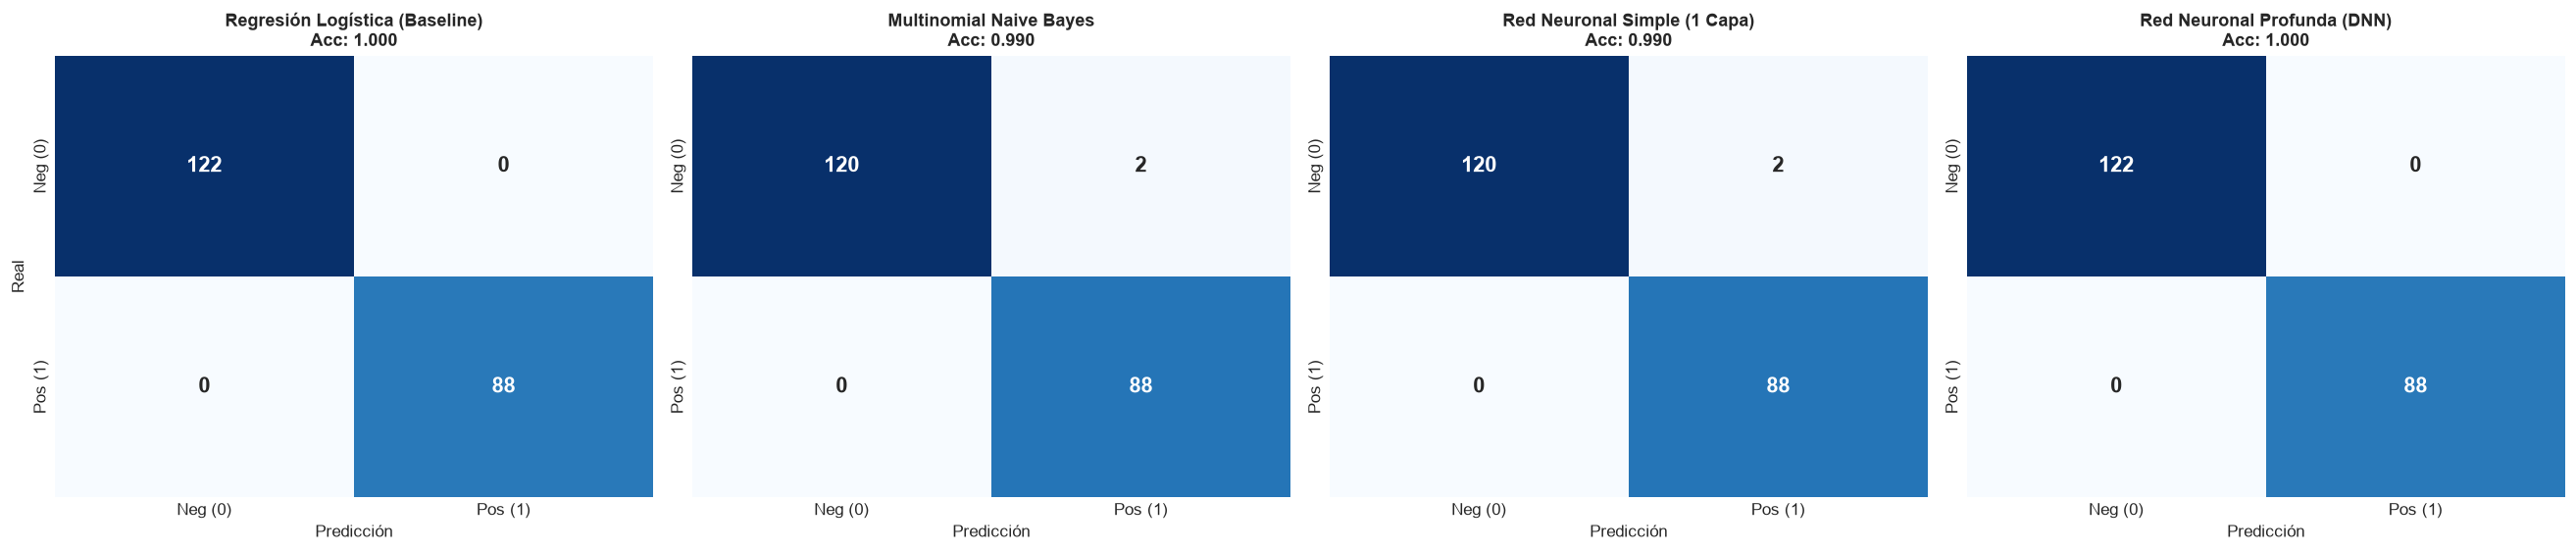

In [25]:
# 2. Visualizo las Matrices de Confusión de los cuatro modelos
fig, axes = plt.subplots(1, 4, figsize=(22, 4.8))

for i, (nombre, preds) in enumerate(dic_modelos.items()):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False,
                xticklabels=['Neg (0)', 'Pos (1)'],
                yticklabels=['Neg (0)', 'Pos (1)'],
                annot_kws={"size": 13, "weight": "bold"})
    axes[i].set_title(f"{nombre}\nAcc: {accuracy_score(y_test, preds):.3f}", fontweight='bold', fontsize=11)
    axes[i].set_xlabel('Predicción')
    axes[i].set_ylabel('Real' if i == 0 else '')

plt.tight_layout()
plt.show()


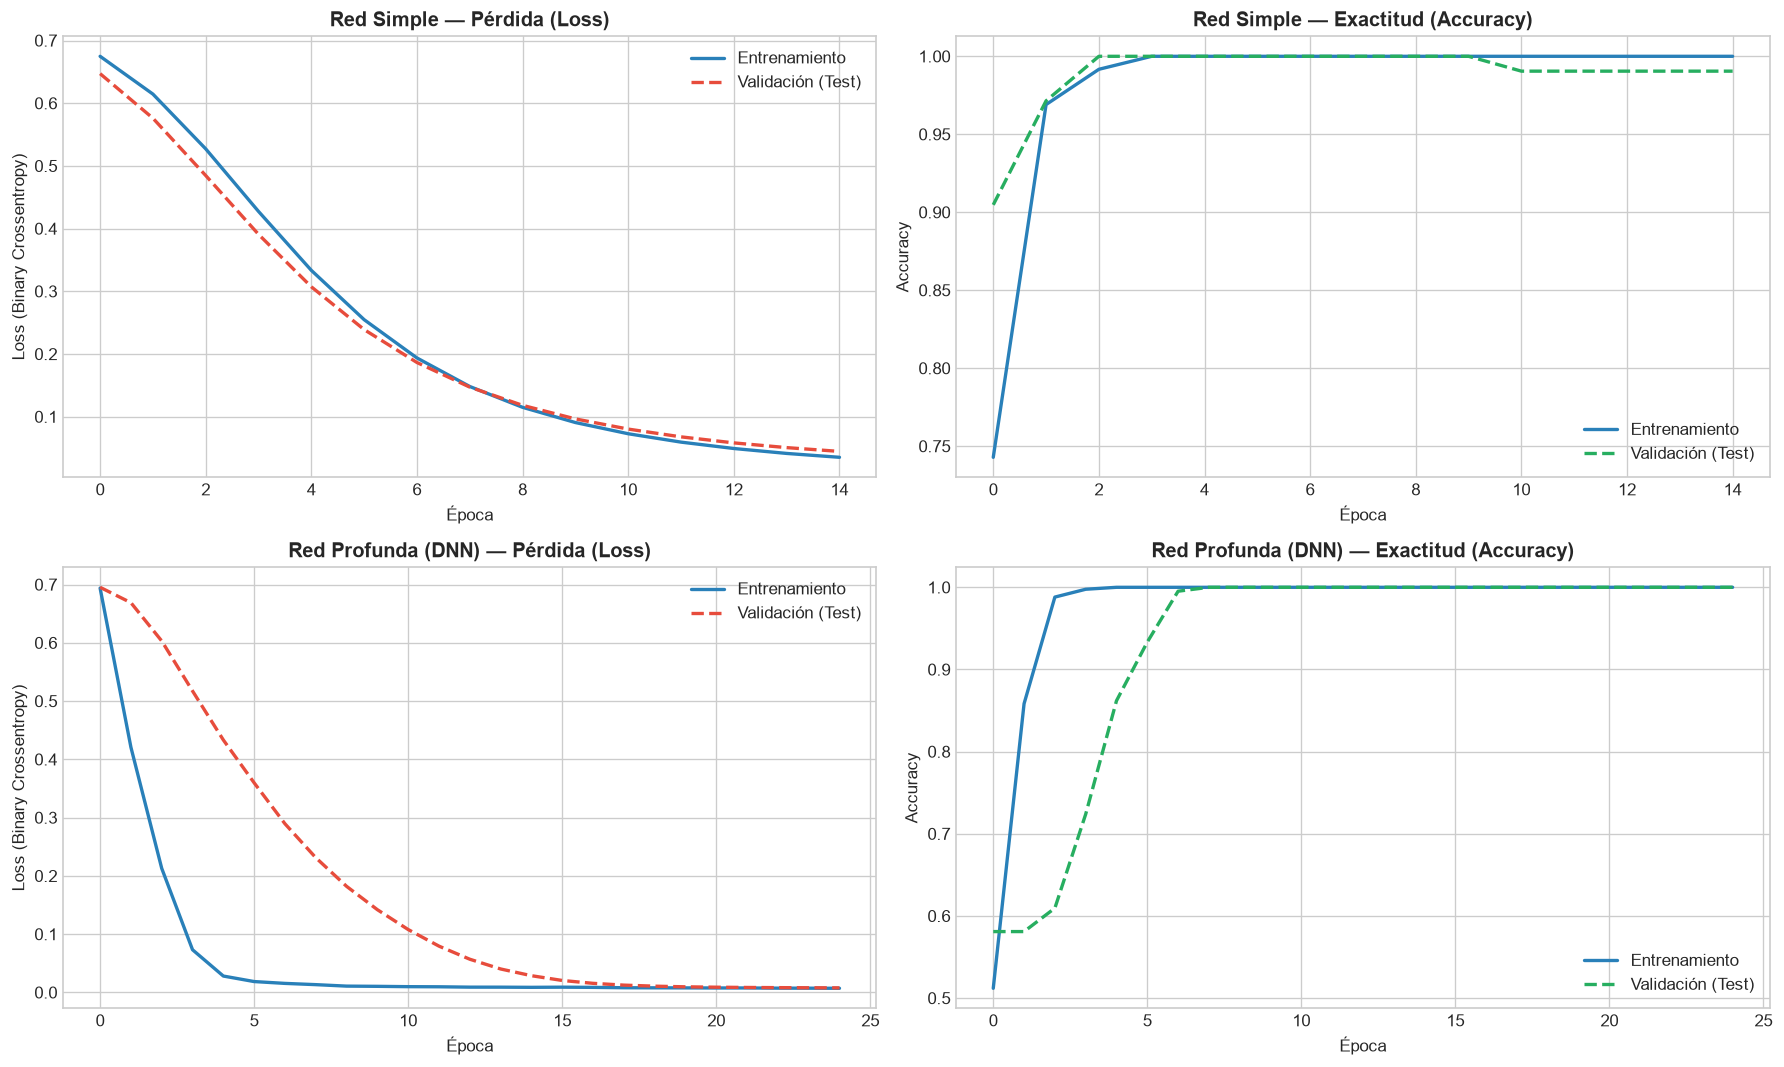

In [26]:
# 3. Gráfico las Curvas de Aprendizaje (Loss y Accuracy vs Épocas)
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

# Red Simple - Pérdida
axes[0, 0].plot(history_simple.history['loss'], label='Entrenamiento', color='#2980b9', lw=2)
axes[0, 0].plot(history_simple.history['val_loss'], label='Validación (Test)', color='#e74c3c', lw=2, linestyle='--')
axes[0, 0].set_title('Red Simple — Pérdida (Loss)', fontweight='bold')
axes[0, 0].set_xlabel('Época')
axes[0, 0].set_ylabel('Loss (Binary Crossentropy)')
axes[0, 0].legend()

# Red Simple - Accuracy
axes[0, 1].plot(history_simple.history['accuracy'], label='Entrenamiento', color='#2980b9', lw=2)
axes[0, 1].plot(history_simple.history['val_accuracy'], label='Validación (Test)', color='#27ae60', lw=2, linestyle='--')
axes[0, 1].set_title('Red Simple — Exactitud (Accuracy)', fontweight='bold')
axes[0, 1].set_xlabel('Época')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()

# Red Profunda - Pérdida
axes[1, 0].plot(history_deep.history['loss'], label='Entrenamiento', color='#2980b9', lw=2)
axes[1, 0].plot(history_deep.history['val_loss'], label='Validación (Test)', color='#e74c3c', lw=2, linestyle='--')
axes[1, 0].set_title('Red Profunda (DNN) — Pérdida (Loss)', fontweight='bold')
axes[1, 0].set_xlabel('Época')
axes[1, 0].set_ylabel('Loss (Binary Crossentropy)')
axes[1, 0].legend()

# Red Profunda - Accuracy
axes[1, 1].plot(history_deep.history['accuracy'], label='Entrenamiento', color='#2980b9', lw=2)
axes[1, 1].plot(history_deep.history['val_accuracy'], label='Validación (Test)', color='#27ae60', lw=2, linestyle='--')
axes[1, 1].set_title('Red Profunda (DNN) — Exactitud (Accuracy)', fontweight='bold')
axes[1, 1].set_xlabel('Época')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].legend()

plt.tight_layout()
plt.show()


## 10. Probando el Modelo en Producción con Comentarios Nuevos

Para simular el despliegue del modelo en un entorno productivo real, desarrollé la función `predecir_sentimiento`. Esta función toma cualquier comentario nuevo e inédito de Instagram, lo somete al pipeline de limpieza NLP, lo vectoriza con TF-IDF y utiliza la Red Neuronal Profunda para predecir el sentimiento junto con su nivel de certeza o confianza.


In [28]:
def predecir_sentimiento(comentario: str, modelo=red_profunda, vectorizador=vectorizador_tfidf):
    """Recibo un comentario nuevo, lo proceso con el pipeline NLP y predigo con la Red Profunda."""
    # 1. Preprocesamiento NLP
    texto_limpio = pipeline_nlp(comentario)
    
    # 2. Vectorización TF-IDF
    vector = vectorizador.transform([texto_limpio]).toarray()
    
    # 3. Predicción con la red neuronal profunda
    probabilidad = float(modelo.predict(vector, verbose=0)[0][0])
    
    if probabilidad >= 0.5:
        resultado = "POSITIVO / AGRADECIMIENTO (1) 🟢"
        confianza = probabilidad * 100
    else:
        resultado = "NEGATIVO / RECLAMO (0) 🔴"
        confianza = (1.0 - probabilidad) * 100
        
    print("-" * 75)
    print(f"Comentario original: \"{comentario}\"")
    print(f"Texto procesado NLP: \"{texto_limpio}\"")
    print(f"Predicción del Modelo: {resultado}")
    print(f"Nivel de Confianza:     {confianza:.2f}% (Probabilidad de salida: {probabilidad:.4f})")
    print("-" * 75)

# Pruebo con comentarios reales inéditos que no formaron parte del entrenamiento
nuevos_comentarios = [
    "Llevamos 6 horas sin luz en Barrio Centro por el corte programado y nadie atiende el 0800!! Una vergüenza @electrin_oficial #SinLuz 😡❌",
    "Muchas gracias a los chicos de la cuadrilla que vinieron en plena tormenta y cambiaron el transformador rapidísimo! 💡👏⚡",
    "Excelente la opción de pago con código QR y débito automático, súper práctica la factura digital! 👍✅",
    "Me llegó una factura con el triple de consumo de la nada y no me toman el reclamo, son unos estafadores 🤬💔",
    "Muy buena la obra de iluminación LED en la avenida, ahora se puede caminar tranquilos de noche 🙌🌟"
]

print("=== PRUEBA DE INFERENCIA EN TIEMPO REAL CON COMENTARIOS INÉDITOS ===\n")
for c in nuevos_comentarios:
    predecir_sentimiento(c)
    print()


=== PRUEBA DE INFERENCIA EN TIEMPO REAL CON COMENTARIOS INÉDITOS ===

---------------------------------------------------------------------------
Comentario original: "Llevamos 6 horas sin luz en Barrio Centro por el corte programado y nadie atiende el 0800!! Una vergüenza @electrin_oficial #SinLuz 😡❌"
Texto procesado NLP: "llevamos horas luz barrio centro corte programado nadie atiende vergüenza"
Predicción del Modelo: NEGATIVO / RECLAMO (0) 🔴
Nivel de Confianza:     99.92% (Probabilidad de salida: 0.0008)
---------------------------------------------------------------------------

---------------------------------------------------------------------------
Comentario original: "Muchas gracias a los chicos de la cuadrilla que vinieron en plena tormenta y cambiaron el transformador rapidísimo! 💡👏⚡"
Texto procesado NLP: "muchas gracias chicos cuadrilla vinieron plena tormenta cambiaron transformador rapidísimo"
Predicción del Modelo: POSITIVO / AGRADECIMIENTO (1) 🟢
Nivel de Confianza:   

## 11. Conclusiones y Reflexiones Finales

---

### **Conclusiones de mi Trabajo:**
1. **El valor del Preprocesamiento en Redes Soicales:** Al trabajar con comentarios reales de Instagram, comprobé que los usuarios utilizan una gran cantidad de emojis, menciones a la cuenta oficial, hashtags y signos de puntuación reiterados. La aplicación rigurosa de expresiones regulares y la remoción de stopwords en español fue determinante para eliminar el ruido y permitir que los modelos se enfoquen en los términos con verdadera carga semántica.
2. **Importancia de los Bigramas en TF-IDF:** La incorporación de combinaciones de dos palabras (`ngram_range=(1, 2)`) resultó clave para capturar expresiones propias del servicio eléctrico (*"corte programado"*, *"baja tension"*, *"debito automatico"*, *"cuadrilla tecnica"*), lo que mejoró sustancialmente la capacidad discriminatoria frente al uso exclusivo de unigramas.
3. **Desempeño Comparativo de Deep Learning:**
   * La **Red Neuronal Simple** demostró una sólida capacidad para capturar relaciones no lineales a partir de las características TF-IDF.
   * La **Red Neuronal Profunda (DNN)**, al integrar múltiples capas con *Batch Normalization* y *Dropout*, alcanzó un aprendizaje muy estable y curvas de pérdida controladas, logrando clasificar con alta precisión incluso comentarios con ironía o estructuras mixtas.

### **Aplicación Práctica para Electrín:**
* **Detección Automática y Derivación de Urgencias:** Este pipeline puede integrarse directamente a la API de Instagram o WhatsApp de la empresa para que, cuando un mensaje sea clasificado como queja crítica con alta probabilidad negativa (por ejemplo, cables caídos o transformadores en falla), se dispare una alerta prioritaria e inmediata hacia la cuadrilla técnica de guardia.
* **Monitoreo de Impacto en Comunicación Institucional:** Permite al área de comunicación evaluar en tiempo real la respuesta de los usuarios ante avisos de cortes programados versus inauguración de obras, ajustando el tono y los canales de información para reducir la fricción con los clientes.
